In [1]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from pathlib import Path

/var/folders/fx/s7zv3zv93zqg5n5t76zy46700000gn/T/ipykernel_51897/291348609.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/var/folders/fx/s7zv3zv93zqg5n5t76zy46700000gn/T/ipykernel_51897/291348609.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/var/folders/fx/s7zv3zv93zqg5n5t76zy46700000gn/T/ipykernel_51897/291348609.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/var/folders/fx/s7zv3zv93zqg5n5t76zy46700000gn/T/ipykernel_51897/291348609.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/var/folders/fx/s7zv3zv9

[ok] combined rows: 1600000 -> combined_apo_p_cont_dihedral_distance.csv


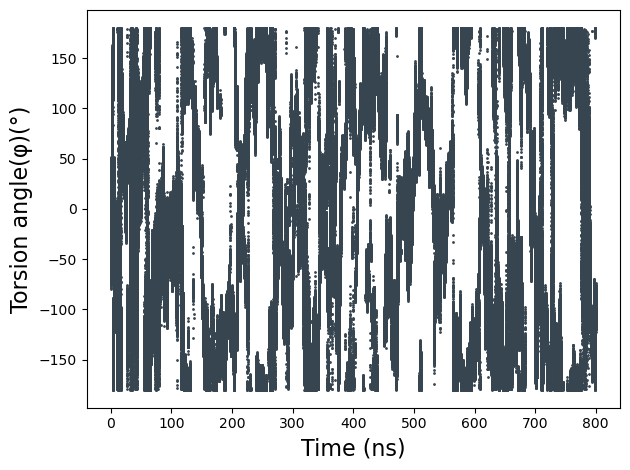

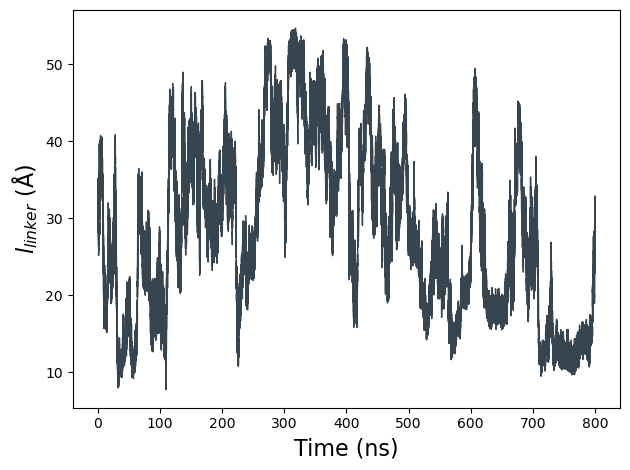

In [2]:
RUN_DIR = "apo_p_hills"   
PREFIX  = "apo_p"       

# go into the folder
os.chdir(RUN_DIR)


def _file_key(name: str):
    import re
    if name.startswith(f"{PREFIX}_meta_cont"):
        m = re.search(rf"{PREFIX}_meta_cont(\d+)\.", name)
        return (1, int(m.group(1)) if m else 10**9, name)
    elif name.startswith(f"{PREFIX}_meta."):
        return (0, 0, name)
    else:
        return (2, 10**9, name)

FILES_IN_ORDER = sorted(
    [p.name for p in Path(".").glob(f"{PREFIX}_meta*.colvars.meta-dihedral.hills.traj")],
    key=_file_key
)

ZERO_REF = 500.0     # reference timestep to make zero
TIMESTEPS_PER_NS = 1e6     # adjust if your time units differ

# ==== READ & COMBINE ====
dfs = []
for fp in FILES_IN_ORDER:
    p = Path(fp)
    if not p.exists():
        print(f"[warn] not found: {fp}")
        continue
    df = pd.read_csv(
        p,
        comment="#",
        delim_whitespace=True,
        header=None,
        usecols=[0, 1, 2],
        names=["timestep", "dihedral", "distance"],
        engine="python",
    )
    for col in ["timestep", "dihedral", "distance"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["timestep", "dihedral", "distance"])
    dfs.append(df)

if len(dfs) == 0:
    raise SystemExit("No valid .traj files found.")

combined = pd.concat(dfs, ignore_index=True)
combined = combined.sort_values("timestep").reset_index(drop=True)

# Shift time and convert to ns
combined["time_shifted"] = combined["timestep"] - ZERO_REF
combined["time_ns"] = combined["time_shifted"] / TIMESTEPS_PER_NS

# Optional: save to CSV
combined.to_csv(f"combined_{PREFIX}_cont_dihedral_distance.csv", index=False)
print(f"[ok] combined rows: {len(combined)} -> combined_{PREFIX}_cont_dihedral_distance.csv")

# helper to remove scientific notation on x-axis
def no_sci_xaxis(ax):
    fmt = ScalarFormatter(useOffset=False)
    fmt.set_scientific(False)
    ax.xaxis.set_major_formatter(fmt)

# ==== PLOTS ====

# torsion (φ) vs time with dots
plt.figure()
plt.plot(combined["time_ns"], combined["dihedral"], ".", markersize=2, color='#36454F')
plt.xlabel("Time (ns)", fontsize=16)
plt.ylabel('Torsion angle(φ)(°)', fontsize=16)
no_sci_xaxis(plt.gca())
plt.tight_layout()
plt.show()

# linker end-to-end distance vs time (line)
plt.figure()
plt.plot(combined["time_ns"], combined["distance"], linewidth=1, color='#36454F')
plt.xlabel("Time (ns)", fontsize=16)
plt.ylabel(r'$l_{\mathit{linker}}$ (Å)', fontsize=16)
no_sci_xaxis(plt.gca())
plt.tight_layout()
plt.show()
# quick look at combined data
#display(combined.head(5))
#display(combined.tail(5))


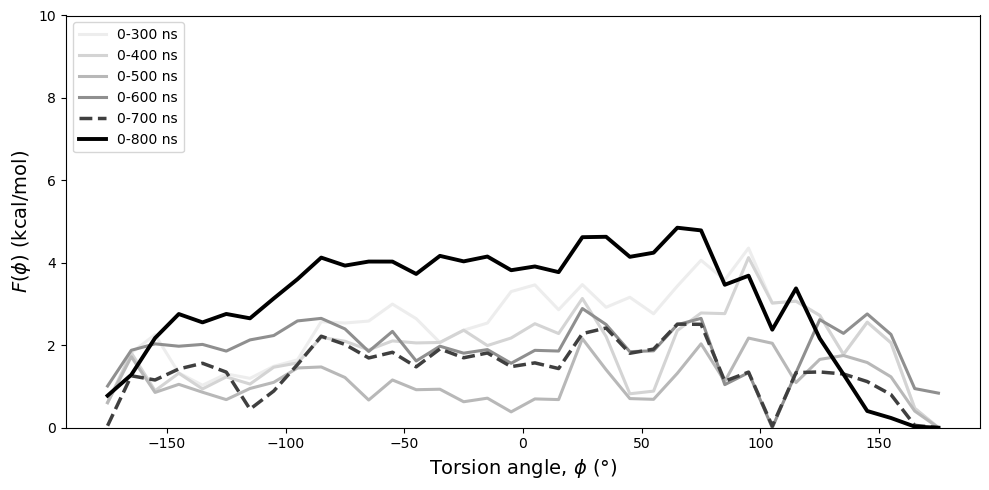

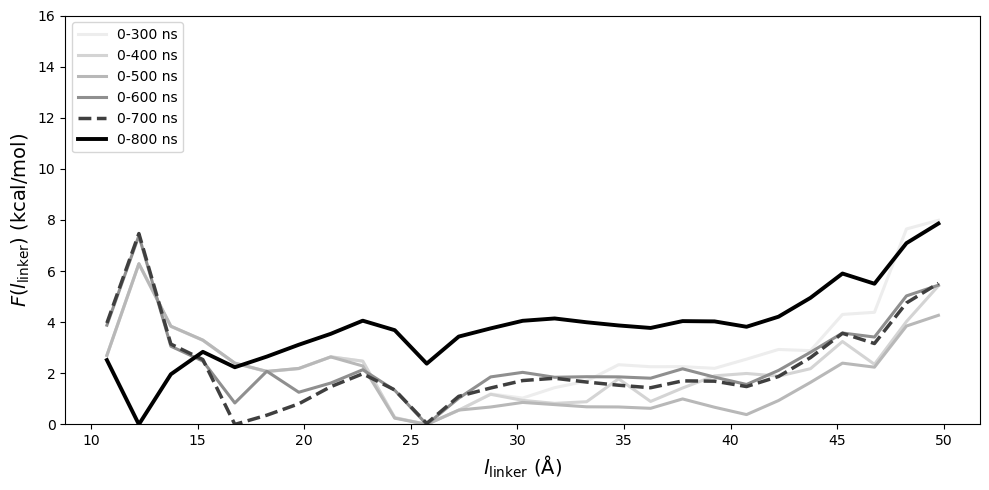

In [3]:
# ==== cumulative free-energy profiles ====

SIM_TEMPERATURE = 310.0
BIAS_TEMPERATURE = 1490.0

CUMULATIVE_ENDS_NS = [300, 400, 500, 600, 700, 800]

FIGSIZE = (10, 5)

# y-axis for cumulative F(phi)
Y_AXIS_RANGE_DIHEDRAL = (0, 10)
Y_TICK_STEP_DIHEDRAL = 2

# y-axis for cumulative F(distance)
Y_AXIS_RANGE_DISTANCE = (0, 15)
Y_TICK_STEP_DISTANCE = 2

# native grid from your colvars setup
DIHEDRAL_LOWER = -180.0
DIHEDRAL_UPPER = 180.0
DIHEDRAL_WIDTH = 10.0

DISTANCE_LOWER = 10.0
DISTANCE_UPPER = 50.0
DISTANCE_WIDTH = 1.5

CUMULATIVE_COLORS = [
    "#ededed",
    "#d4d4d4",
    "#b8b8b8",
    "#8f8f8f",
    "#3f3f3f",
    "#000000",
]

CUMULATIVE_LINESTYLES = [
    "-",
    "-",
    "-",
    "-",
    "--",
    "-",
]

CUMULATIVE_LINEWIDTHS = [
    2.2,
    2.2,
    2.2,
    2.2,
    2.5,
    2.8,
]

WTMETA_FACTOR = -(SIM_TEMPERATURE + BIAS_TEMPERATURE) / BIAS_TEMPERATURE


def wrap_dihedral_delta(x, x0):
    d = x - x0
    return (d + 180.0) % 360.0 - 180.0

def make_native_grid():
    n_phi = int(round((DIHEDRAL_UPPER - DIHEDRAL_LOWER) / DIHEDRAL_WIDTH))
    n_dist = int(round((DISTANCE_UPPER - DISTANCE_LOWER) / DISTANCE_WIDTH))

    phi_grid = DIHEDRAL_LOWER + DIHEDRAL_WIDTH * (0.5 + np.arange(n_phi))
    dist_grid = DISTANCE_LOWER + DISTANCE_WIDTH * (0.5 + np.arange(n_dist))

    return phi_grid, dist_grid

def read_hills_full(file_list):
    dfs = []

    for fp in file_list:
        p = Path(fp)
        if not p.exists():
            print(f"[warn] not found: {fp}")
            continue

        df = pd.read_csv(
            p,
            comment="#",
            sep=r"\s+",
            header=None,
            usecols=[0, 1, 2, 3, 4, 5],
            names=["timestep", "dihedral", "distance", "sigma_phi", "sigma_dist", "height"],
            engine="python",
        )

        for col in ["timestep", "dihedral", "distance", "sigma_phi", "sigma_dist", "height"]:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        df = df.dropna(
            subset=["timestep", "dihedral", "distance", "sigma_phi", "sigma_dist", "height"]
        ).copy()

        dfs.append(df)

    if len(dfs) == 0:
        raise SystemExit("No valid hills files found.")

    out = pd.concat(dfs, ignore_index=True)
    out = out.sort_values("timestep").reset_index(drop=True)
    out["time_shifted"] = out["timestep"] - ZERO_REF
    out["time_ns"] = out["time_shifted"] / TIMESTEPS_PER_NS

    return out

def reconstruct_bias_on_grid(hills_df, phi_grid, dist_grid):
    Phi, Dist = np.meshgrid(phi_grid, dist_grid, indexing="ij")
    V = np.zeros_like(Phi, dtype=float)

    for _, row in hills_df.iterrows():
        dphi = wrap_dihedral_delta(Phi, row["dihedral"])
        ddist = Dist - row["distance"]

        hill = row["height"] * np.exp(
            -0.5 * (dphi / row["sigma_phi"]) ** 2
            -0.5 * (ddist / row["sigma_dist"]) ** 2
        )
        V += hill

    return V

def bias_to_free_energy(V, factor=WTMETA_FACTOR):
    F = factor * V
    F = F - np.nanmin(F)
    return F

def project_f_dihedral(F_2d):
    Fphi = np.nanmin(F_2d, axis=1)
    Fphi = Fphi - np.nanmin(Fphi)
    return Fphi

def project_f_distance(F_2d):
    Fd = np.nanmin(F_2d, axis=0)
    Fd = Fd - np.nanmin(Fd)
    return Fd

def apply_manual_yaxis(ax, y_axis_range=None, y_tick_step=None):
    if y_axis_range is not None:
        ax.set_ylim(*y_axis_range)
    if y_axis_range is not None and y_tick_step is not None:
        ymin, ymax = y_axis_range
        ax.set_yticks(np.arange(ymin, ymax + y_tick_step, y_tick_step))

def plot_cumulative_profile(
    xgrid,
    all_hills,
    projector,
    xlabel,
    ylabel,
    phi_grid,
    dist_grid,
    y_axis_range=None,
    y_tick_step=None,
):
    fig, ax = plt.subplots(figsize=FIGSIZE)

    for t_end, color, linestyle, linewidth in zip(
        CUMULATIVE_ENDS_NS,
        CUMULATIVE_COLORS,
        CUMULATIVE_LINESTYLES,
        CUMULATIVE_LINEWIDTHS,
    ):
        hills_cum = all_hills[
            (all_hills["time_ns"] >= 0) &
            (all_hills["time_ns"] <= t_end)
        ].copy()

        if hills_cum.empty:
            print(f"[warn] empty cumulative hills window: 0-{t_end} ns")
            continue

        V_cum = reconstruct_bias_on_grid(hills_cum, phi_grid, dist_grid)
        F_cum = bias_to_free_energy(V_cum)
        F_proj = projector(F_cum)

        ax.plot(
            xgrid,
            F_proj,
            color=color,
            linestyle=linestyle,
            linewidth=linewidth,
            label=f"0-{t_end} ns",
        )

    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    apply_manual_yaxis(ax, y_axis_range=y_axis_range, y_tick_step=y_tick_step)
    ax.legend(loc="upper left", frameon=True)
    plt.tight_layout()
    plt.show()

# -----------------------------
# build grids and read hills
# -----------------------------
phi_grid, dist_grid = make_native_grid()
all_hills = read_hills_full(FILES_IN_ORDER)

# -----------------------------
# cumulative F(phi)
# -----------------------------
plot_cumulative_profile(
    xgrid=phi_grid,
    all_hills=all_hills,
    projector=project_f_dihedral,
    xlabel=r"Torsion angle, $\phi$ (°)",
    ylabel=r"$F(\phi)$ (kcal/mol)",
    phi_grid=phi_grid,
    dist_grid=dist_grid,
    y_axis_range=Y_AXIS_RANGE_DIHEDRAL,
    y_tick_step=Y_TICK_STEP_DIHEDRAL,
)

# -----------------------------
# cumulative F(distance)
# -----------------------------
plot_cumulative_profile(
    xgrid=dist_grid,
    all_hills=all_hills,
    projector=project_f_distance,
    xlabel=r"$l_{\mathrm{linker}}$ (Å)",
    ylabel=r"$F(l_{\mathrm{linker}})$ (kcal/mol)",
    phi_grid=phi_grid,
    dist_grid=dist_grid,
    y_axis_range=Y_AXIS_RANGE_DISTANCE,
    y_tick_step=Y_TICK_STEP_DISTANCE,
)